# Lenet-5 for MNIST Digit Recognition

Implementation based on the [original paper](http://vision.stanford.edu/cs598_spring07/papers/Lecun98.pdf) with minimal differences. Whenever I take a different approach than the paper, I point it out.

In [1]:
import importlib
import torch
import torchvision
import scorch
import wandb

In [2]:
config = {
    'batch_size': 128,
    'epochs': 20,
    'lr': 0.001,
    'lr_gamma': 0.9
}

In [3]:
wandb.init(project="lenet-5", config=config)


wandb: Currently logged in as: fszewczyk to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Normalization

The paper describes that data is normalized so that background corresponds to -0.1 and foreground to 1.175. I calculate the assumed mean and std from these values.

In [4]:
dataset_path = "./datasets/mnist"

# background and foreground values from the paper
# out = (in - mean) / std
# -0.1 = (0 - mean) / std => -0.1 = -mean / std => mean = 0.1std
# 1.175 = (1 - mean) / std => 1.175std = 1 - mean => 1.175std - 1 = -mean => mean = 1 - 1.175std
# => 0.1std = 1 - 1.175std => 1.275std = 1 => std = 0.78 => mean = 0.078

transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Pad(2, fill=0),
    torchvision.transforms.Normalize(mean=0.078, std=0.78)
])
label_transform = torchvision.transforms.Compose([
    lambda label: torch.tensor([label]),
    lambda label: torch.nn.functional.one_hot(label, num_classes=10).squeeze().float()
])

train_dataset_base = torchvision.datasets.MNIST(dataset_path, transform=transforms, target_transform=label_transform, train=True, download=True)
test_dataset_base = torchvision.datasets.MNIST(dataset_path, transform=transforms, target_transform=label_transform, train=False, download=True)
train_dataloader = torch.utils.data.DataLoader(train_dataset_base, batch_size=config['batch_size'], shuffle=True)
test_dataloader = torch.utils.data.DataLoader(test_dataset_base, batch_size=config['batch_size'])

## Architecture

Replicates the model described in the paper, but I do not encode each digit with a hardcoded 7x12 bitmap so it can be used in an Euclidean Radial Basis Function. Instead, I use Softmax to directly compute probabilities over classes

In [5]:
class SubSampling(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.coefficient = torch.nn.Parameter(torch.rand(size=(1,)) * 2 - 1)
        self.bias = torch.nn.Parameter(torch.rand(size=(1,)) * 2 - 1)
        self.tanh = scorch.nn.Tanh()

    def forward(self, x):
        polled = torch.nn.functional.avg_pool2d(x, kernel_size=2, stride=2)
        return self.tanh(self.coefficient * polled + self.bias)

In [6]:
class SparseConv2D(torch.nn.Module):
    def __init__(self, connectivity_table):
        super().__init__()

        self.conv = scorch.nn.Conv2D(in_channels=6, out_channels=16, kernel_size=5)
        mask = torch.zeros_like(self.conv.weights)

        for in_ch, out_ch in connectivity_table:
            mask[out_ch, in_ch] = 1

        self.register_buffer('mask', mask)

    def forward(self, x):
        self.conv.weights *= self.mask
        return self.conv(x)

In [7]:
connectivity_table = [
    (0, 0), (0, 4), (0, 5), (0, 6), (0, 9), (0, 10), (0, 11), (0, 12), (0, 14), (0, 15),
    (1, 0), (1, 1), (1, 5), (1, 6), (1, 7), (1, 10), (1, 11), (1, 12), (1, 13), (1, 15),
    (2, 0), (2, 1), (2, 2), (2, 6), (2, 7), (2, 8), (2, 11), (2, 13), (2, 14), (2, 15),
    (3, 1), (3, 2), (3, 3), (3, 6), (3, 7), (3, 8), (3, 9), (3, 12), (3, 14), (3, 15),
    (4, 2), (4, 3), (4, 4), (4, 7), (4, 8), (4, 9), (4, 10), (4, 12), (4, 13), (4, 15),
    (5, 3), (5, 4), (5, 5), (5, 8), (5, 9), (5, 10), (5, 11), (5, 13), (5, 14), (5, 15)
]

lenet = torch.nn.Sequential(
    # C1
    scorch.nn.Conv2D(in_channels=1, out_channels=6, kernel_size=5),
    scorch.nn.Tanh(),
    # S2
    SubSampling(),
    # C3
    scorch.nn.Conv2D(in_channels=6, out_channels=16, kernel_size=5),
    scorch.nn.Tanh(),
    # S4
    SubSampling(),
    # C5
    scorch.nn.Conv2D(in_channels=16, out_channels=120, kernel_size=5),
    scorch.nn.Flatten(),
    scorch.nn.Tanh(),
    # F6
    scorch.nn.Linear(120, 84),
    scorch.nn.Tanh(),
    # OUTPUT
    scorch.nn.Linear(84, 10), # paper has RBF connections, but I'll skip that
)

In [8]:
loss_logger = scorch.execution.LossLogger(
    epochs=config['epochs'],
    train_batches=len(train_dataloader),
    valid_batches=len(test_dataloader),
    log_wandb=True,
    log_console=True
)

classification_logger = scorch.execution.ClassifierLogger(
    classes=10,
    index_to_name=[str(i) for i in range(10)],
    epochs=config['epochs'],
    log_detailed_on_last_epoch=True,
    log_wandb=True,
    log_console=True
)

lr_logger = scorch.execution.LearningRateLogger(
    log_console=False,
    log_wandb=True
)

In [9]:
optimizer = torch.optim.Adam(lenet.parameters(), lr=config['lr'])

In [10]:
trainer = scorch.execution.Runner(
    model=lenet,
    training_loader=train_dataloader,
    optimizer=optimizer,
    lr_scheduler=torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=config['lr_gamma']),
    loss=scorch.nn.CrossEntropyLoss,
    epochs=config['epochs'],
    validation_loader=test_dataloader,
    loggers=(
        loss_logger,
        classification_logger,
        lr_logger
    )
)

Using device: cuda


In [11]:
stats = trainer.run(train=True, validate=True)

Epoch 1/20
	Epoch Train Loss: 0.9230663180351257
	Epoch Validation Loss: 0.2298709899187088
Epoch 1/20 Error Rates
	Top-1 Train: 0.32150630770461647
	Top-3 Train: 0.18510683182714335
	Top-5 Train: 0.11722081556503199
	Top-10 Train: 0.0
	Top-1 Validation: 0.07090585443037975
	Top-3 Validation: 0.009295886075949366
	Top-5 Validation: 0.0020767405063291137
	Top-10 Validation: 0.0
Epoch 2/20
	Epoch Train Loss: 0.18098658323287964
	Epoch Validation Loss: 0.1263062208890915
Epoch 2/20 Error Rates
	Top-1 Train: 0.0561256218058214
	Top-3 Train: 0.0078013947269301425
	Top-5 Train: 0.0020378019763970935
	Top-10 Train: 0.0
	Top-1 Validation: 0.0379746835443038
	Top-3 Validation: 0.004153481012658227
	Top-5 Validation: 0.0007911392405063291
	Top-10 Validation: 0.0
Epoch 3/20
	Epoch Train Loss: 0.11246923357248306
	Epoch Validation Loss: 0.09016606956720352
Epoch 3/20 Error Rates
	Top-1 Train: 0.03444274160653543
	Top-3 Train: 0.004231076759061834
	Top-5 Train: 0.000882862473347548
	Top-10 Train: 0

## Quantitative Results

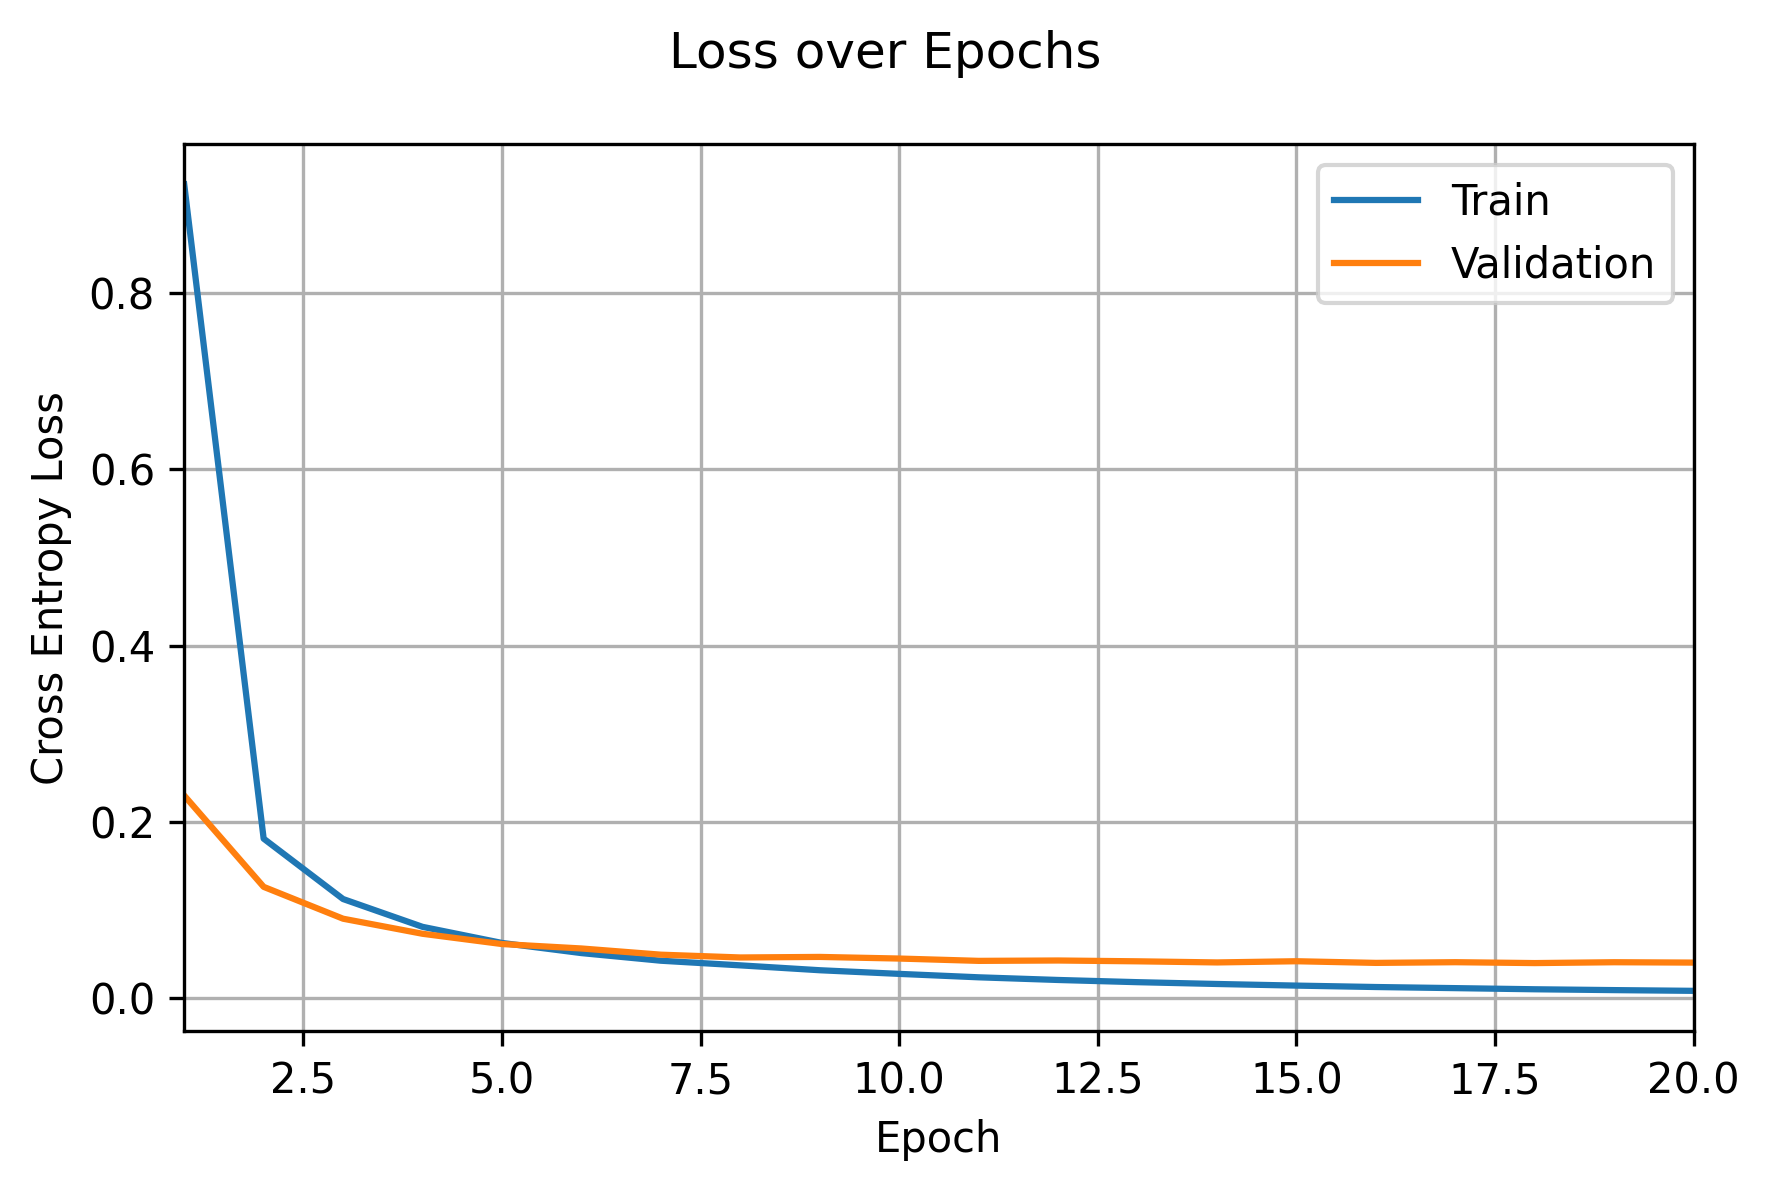

In [12]:
loss_logger.plot(ylabel='Cross Entropy Loss')


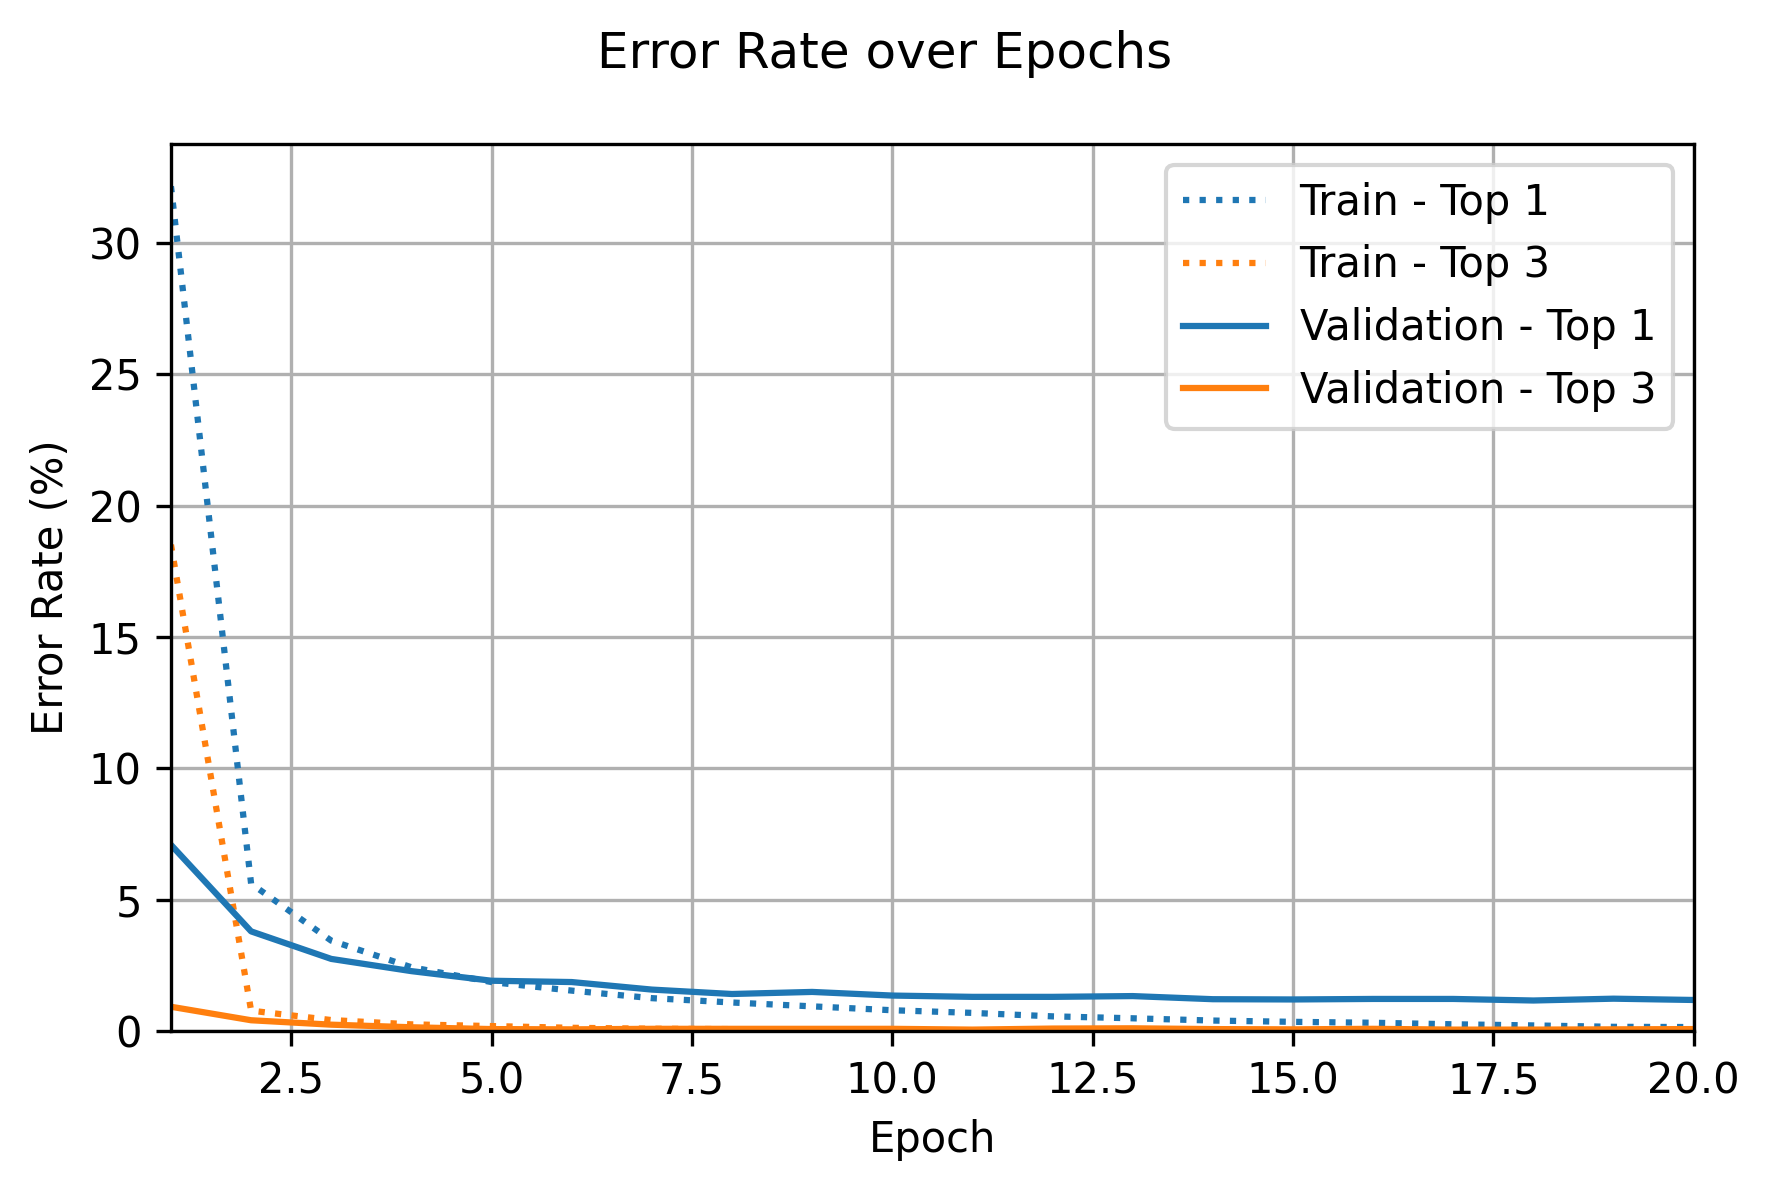

In [13]:
classification_logger.plot_error_rates(ks=(1, 3))


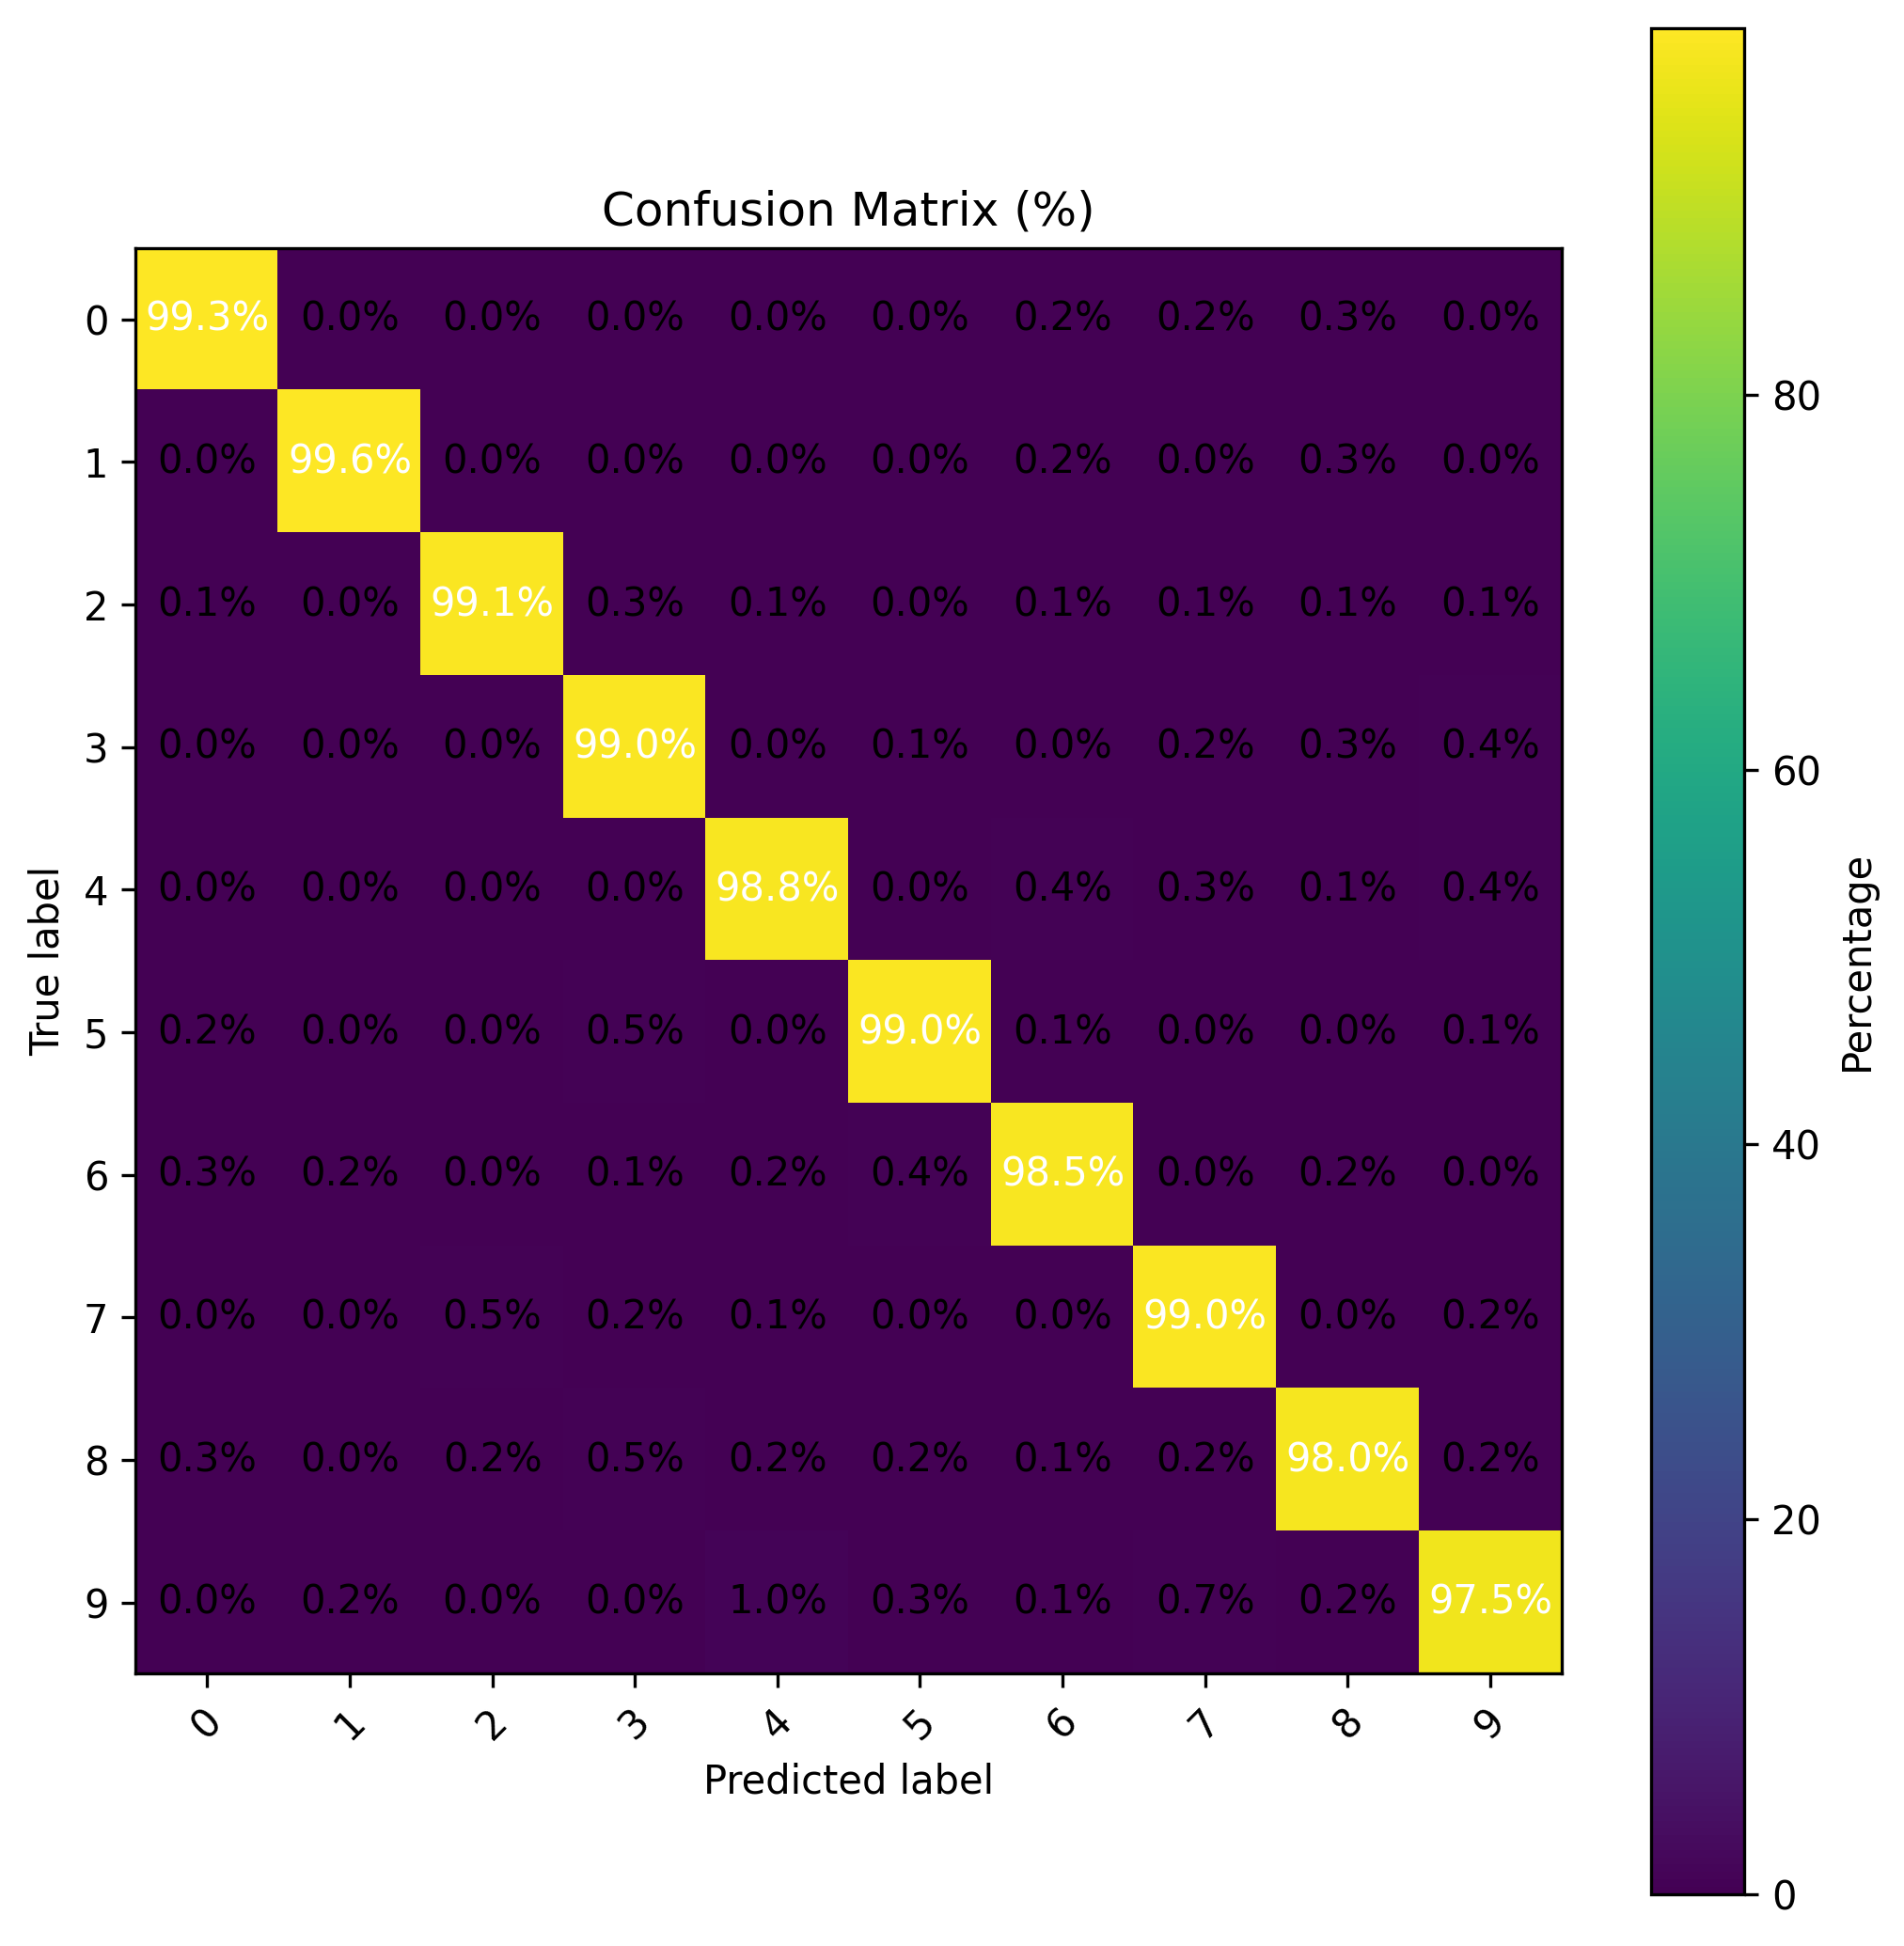

In [14]:
classification_logger.plot_confusion_matrix()


## Qualitative Results

In [15]:
predictions_by_confidence = sorted(classification_logger.valid['predictions'][-1], key=lambda p: -p.confidence)
wrong_predictions = list(filter(lambda p: not p.correct, predictions_by_confidence))
correct_predictions = list(filter(lambda p: p.correct, predictions_by_confidence))

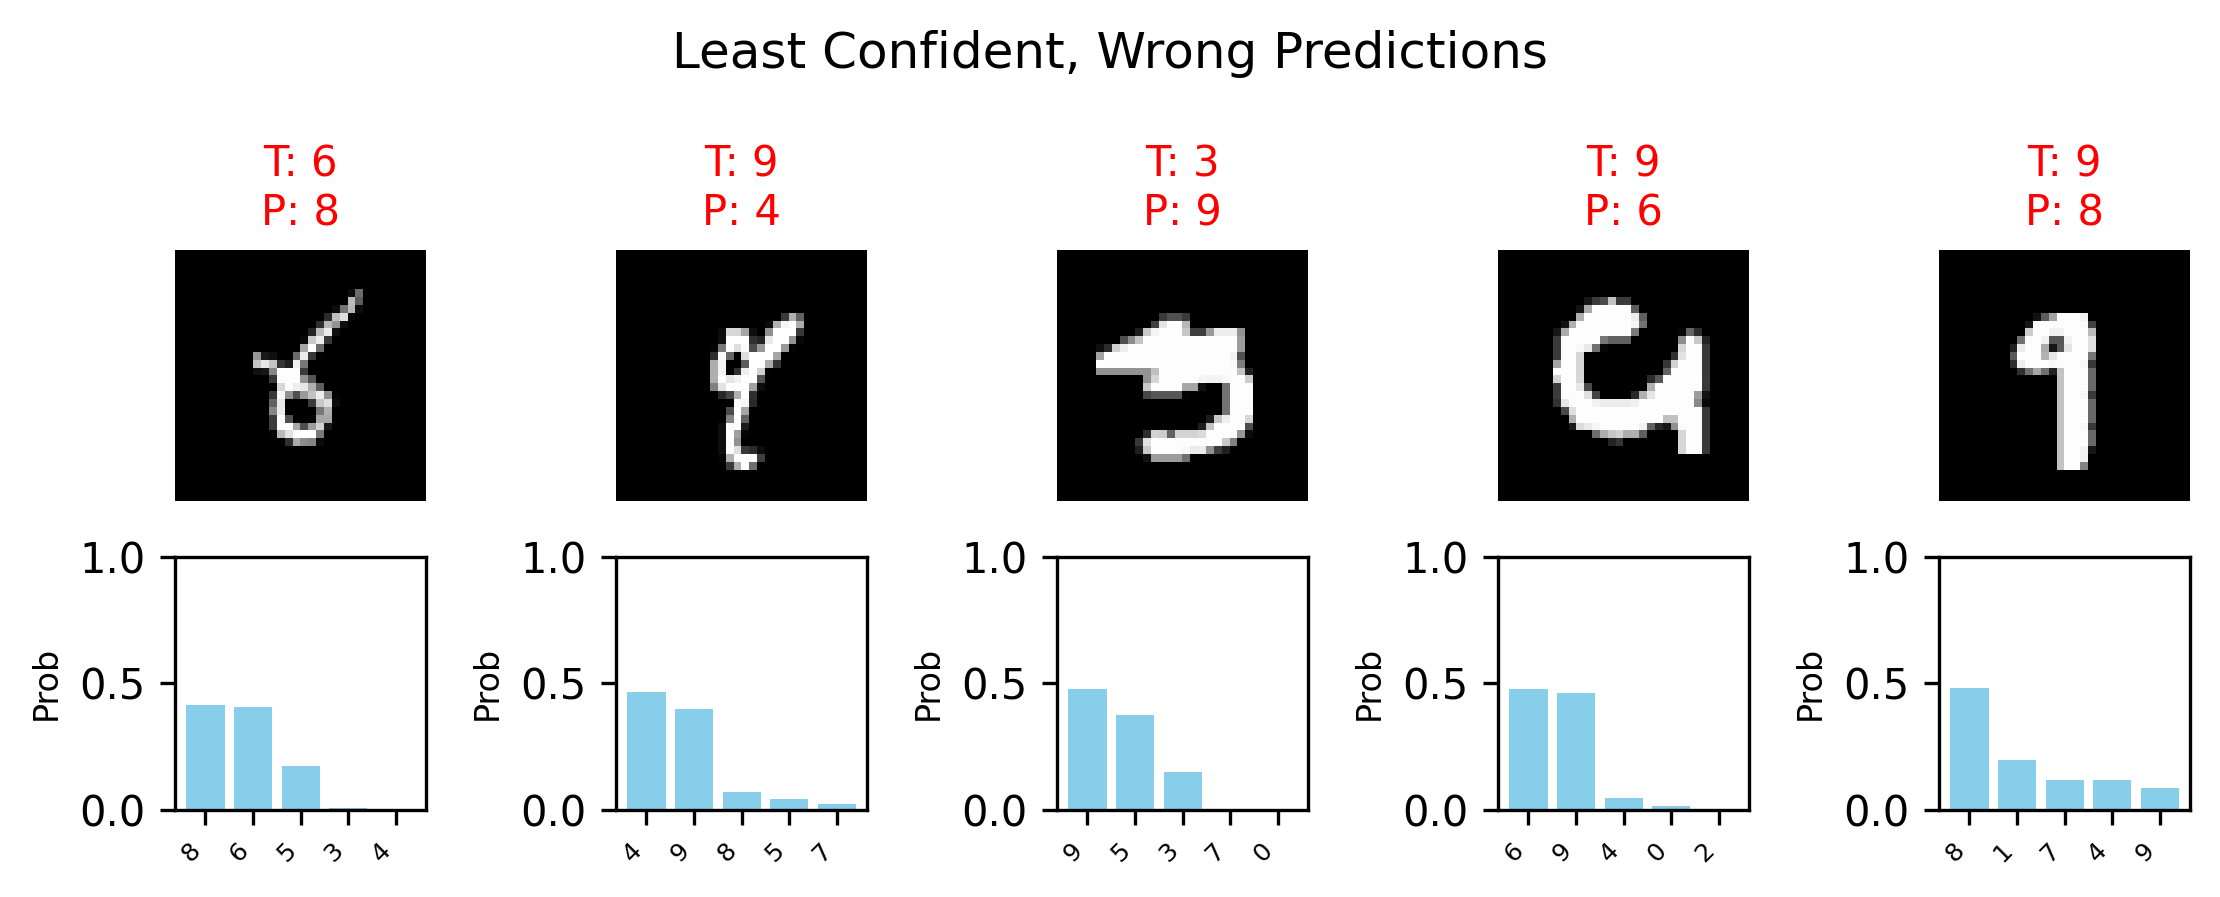

In [16]:
scorch.execution.ClassifierLogger.plot_predictions_for_images(wrong_predictions[::-1][:5], title='Least Confident, Wrong Predictions')

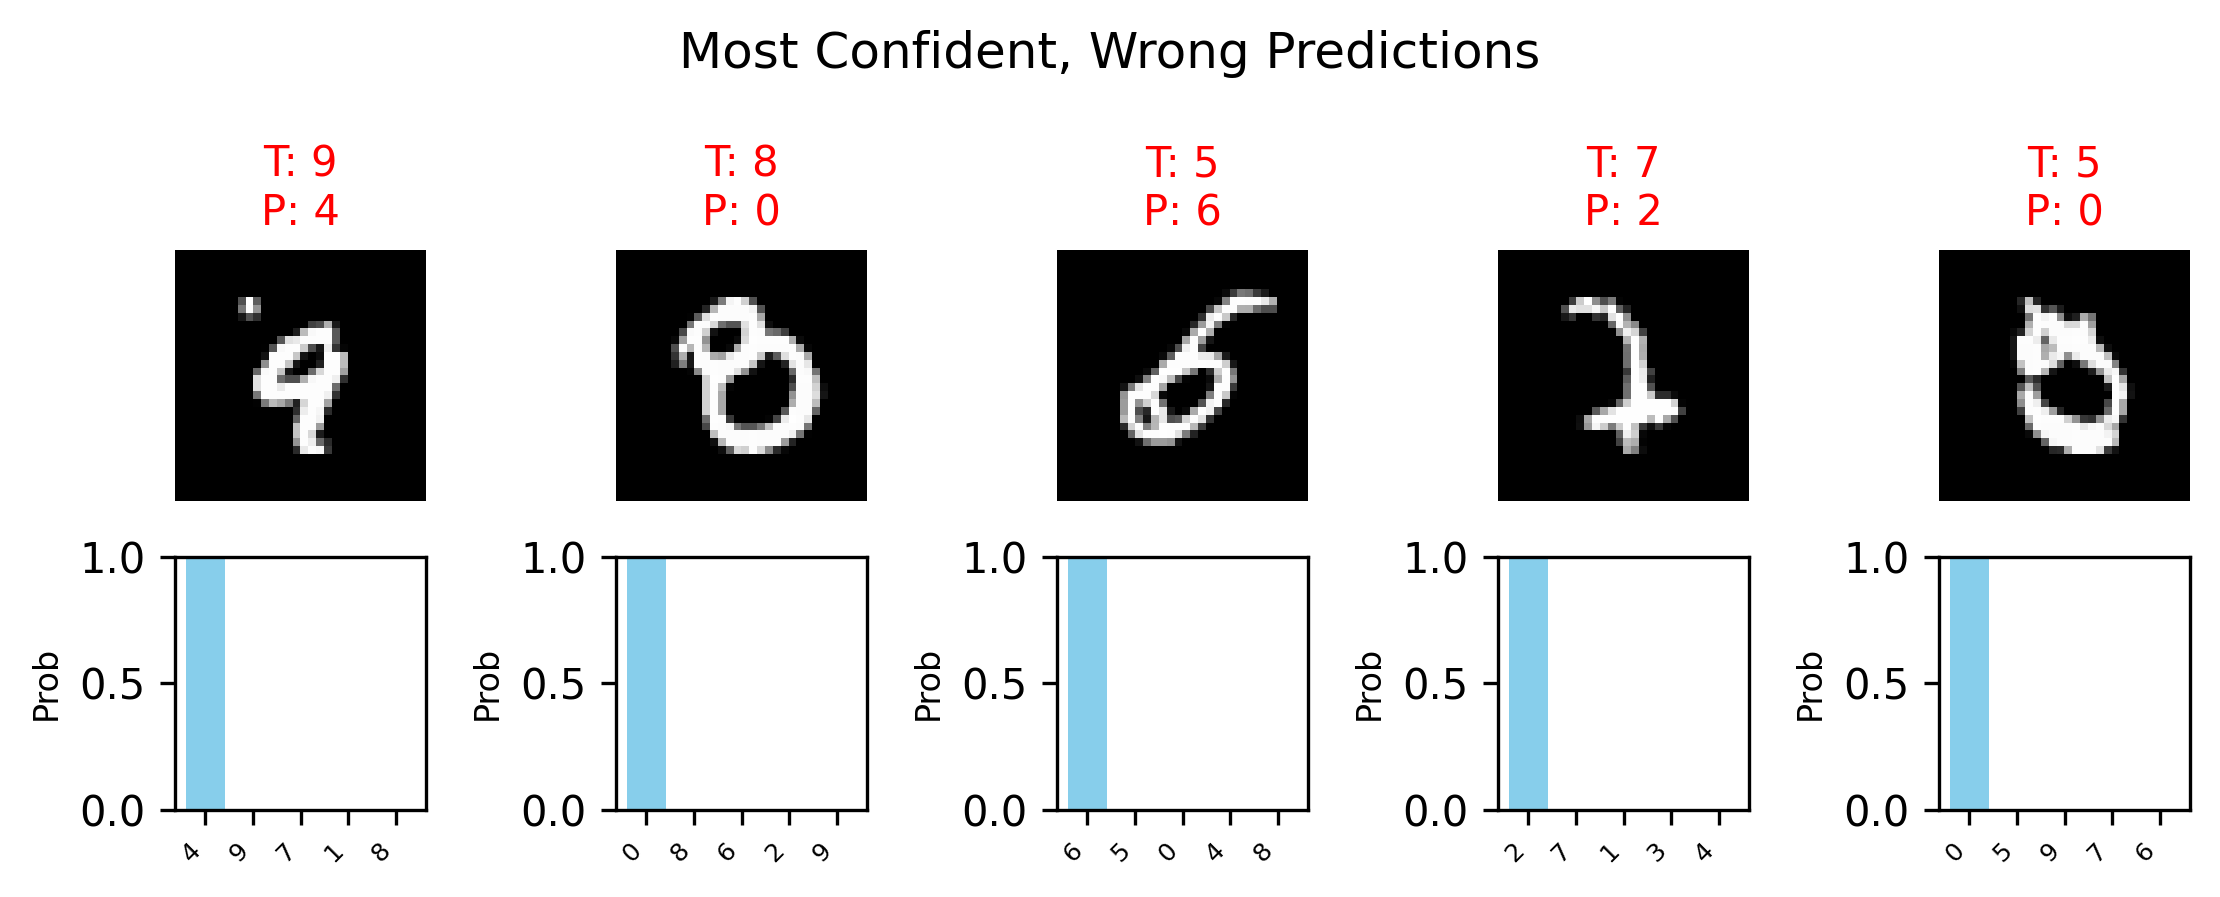

In [17]:
scorch.execution.ClassifierLogger.plot_predictions_for_images(wrong_predictions[:5], title='Most Confident, Wrong Predictions')


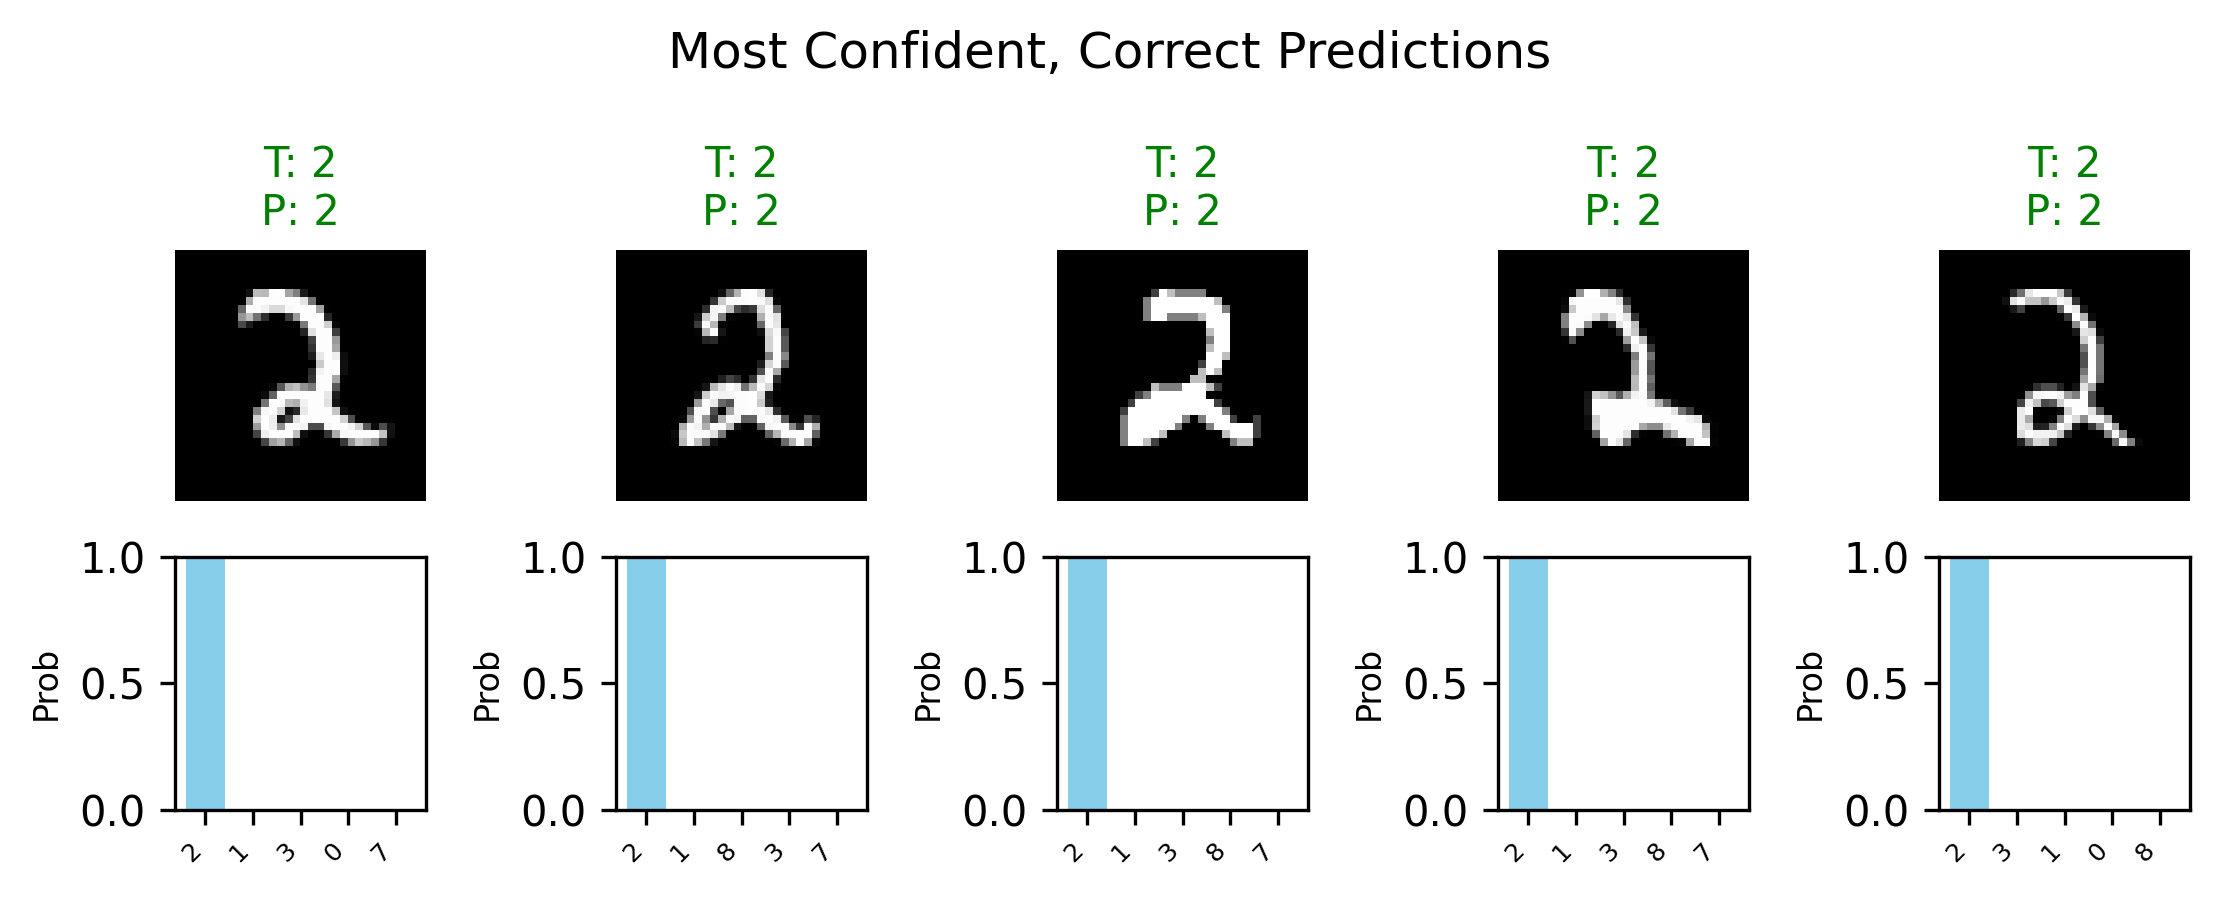

In [18]:
scorch.execution.ClassifierLogger.plot_predictions_for_images(correct_predictions[:5], title='Most Confident, Correct Predictions')

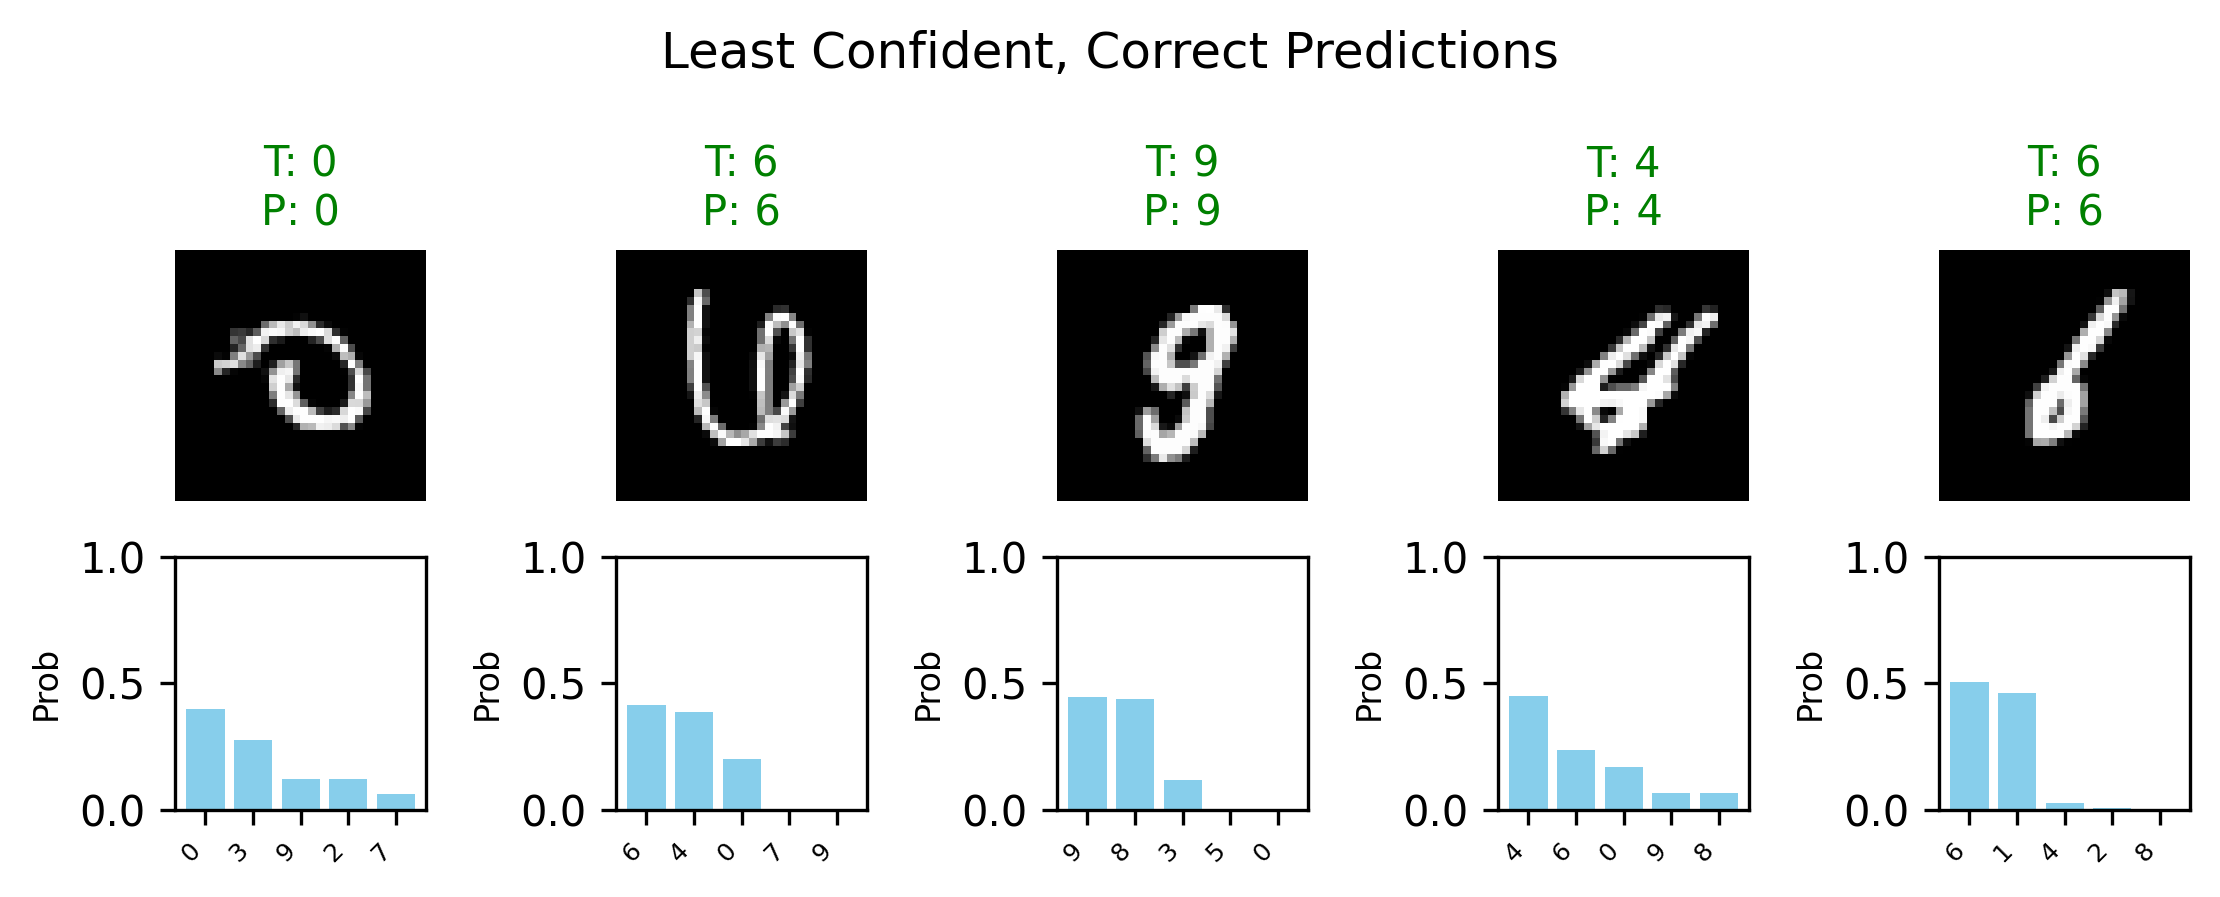

In [19]:
scorch.execution.ClassifierLogger.plot_predictions_for_images(correct_predictions[::-1][:5], title='Least Confident, Correct Predictions')

In [20]:
wandb.finish()


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


batch,▁
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
lr/group-0,█▇▆▆▅▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁
train/loss_epoch,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/top-1,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/top-10,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/top-3,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/top-5,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
valid/loss_epoch,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
valid/top-1,█▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
+3,...
